In [34]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt


In [35]:
X_train = np.array([[4, 5, 1, 5], [6, 3, 2, 4], [8, 2, 1, 3]])
y_train = np.array([4, 2, 8])

In [49]:
X_train = (X_train - X_train.mean()) / X_train.std()

In [43]:
# single 
def pred(w,x,b):
    p = np.dot(w,x)
    p = p + b
    return p 

In [44]:
def pred_vec(X, w, b):
    outer = X.shape[0]
    inner = X.shape[1]
    pre = np.zeros(outer)

    for i in range(outer):
        s = 0      
        for j in range(inner):
            try:
                s += X[i][j] * w[j]
            except:
                pass
        try:
            pre[i] = s + b
        except:
            pass
    return pre

In [45]:
# cost 
def cost(predicted, actual):
    err = 0
    n = predicted.shape[0]
    for i in range(n):
        err += (predicted[i] - actual[i])**2
    return err/n    

In [46]:
def gra(actual, predicted, l_rate, X_train, w, b):
    n = predicted.shape[0]
    outer =X_train.shape[0]
    inner =X_train.shape[1]
    D_w = np.zeros(inner)
    D_b = 0 
    
    

    for i in range(outer):
        err = predicted[i] - actual[i]
        for I in range(inner):
            D_w[I] += 2 * X_train[i][I] * err
        D_b += 2 * err

    D_b /= n
    D_w /= n

    for j in range(inner):
        try:
            w[j] -= l_rate * D_w[j]
        except:
            pass

    b -= l_rate * D_b
    return w, b


In [47]:
w = np.array([1,2,3,4])   # weight
bias = 0.0   # bias
learning_rate = 0.0001
cost_history = list()
epoches = range(50)
for epoch in epoches:
    predictions = pred_vec(X_train,w,bias)
    costs = cost(predictions, y_train)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Cost: {costs}")
    w,bias=gra(y_train, predictions, learning_rate, X_train, w, bias)
    cost_history.append(costs)
print(w,bias)

Epoch 0, Cost: 63.19875084527007
Epoch 10, Cost: 16.181742893905753
Epoch 20, Cost: 16.137350073186244
Epoch 30, Cost: 16.0931344867687
Epoch 40, Cost: 16.04909542706127
[1 0 0 1] 0.03450754915187095


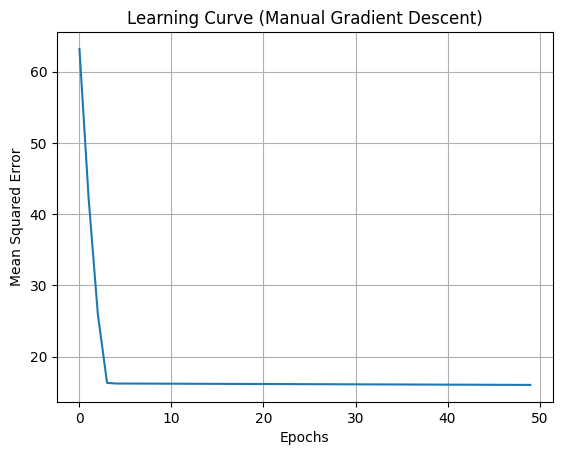

In [48]:
plt.figure()
plt.plot(epoches, cost_history)
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve (Manual Gradient Descent)")
plt.grid()
plt.show()